# Reflection + Evaluator-Optimizer

Agent가 자기 출력을 검토하고 개선하는 패턴을 배운다.

In [2]:
from operator import add
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field


load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### Reflection 패턴

가장 단순한 자기 개선 루프다.

```
START → generate → should_continue? → END (종료)
          ↑                │ continue
          └──── reflect ←──┘
```

동작 순서:

1. **generate** 노드가 초안을 작성한다
2. **should_continue**가 반복 횟수를 체크한다 — 상한에 도달하면 최종 초안을 남기고 종료한다
3. 종료 전이면 **reflect** 노드가 초안을 읽고 피드백을 준다 (톤, 빠진 정보, 길이 등)
4. 피드백을 반영해 다시 generate로 돌아간다

State에 `messages`를 누적하므로 generate 노드는 이전 피드백을 자연스럽게 참고한다.

### Reflection 실습

시나리오: 고객에게 보내는 사과 이메일 초안을 작성하고, 반복적으로 개선한다.

In [4]:
class ReflectionState(TypedDict):
    messages: Annotated[list, add_messages]
    iteration: int


MAX_ITERATIONS = 3
generator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
reviewer_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

In [5]:
def generate(state: ReflectionState):
    """초안을 작성하거나 피드백을 반영해 수정한다."""
    system = SystemMessage(content="""
너는 고객 지원 이메일 작성 전문가다.

사용자의 요청에 맞는 이메일을 작성하라. 대화에 리뷰 피드백이 있으면 빠짐없이 반영하되,
피드백이나 수정 과정을 언급하지 말고 자연스럽게 완성된 이메일로 작성하라.

작성 원칙:
- 상황과 책임을 명확하게 설명한다.
- 진정성 있게 사과하고 구체적인 해결 방안을 안내한다.
- 불필요하게 장황하거나 과장된 표현은 피한다.
- 사용자가 제공한 이름, 주문번호 등 사실을 정확하게 유지한다.

출력 형식:
- 이메일 본문만 출력한다.
- 작성 과정, 해설, 머리말은 출력하지 않는다.
""")
    # 전체 messages를 넘기면 generate는 이전 피드백까지 자연스럽게 참고한다
    response = generator_llm.invoke([system, *state["messages"]])
    return {
        "messages": [AIMessage(content=response.text)],
        "iteration": state.get("iteration", 0) + 1,
    }


def reflect(state: ReflectionState):
    """초안을 검토하고 구체적인 피드백을 준다."""
    system = SystemMessage(content="""
너는 고객 지원 이메일 편집자다. 주어진 초안을 검토하고 다음 수정에 바로 사용할 수 있는
구체적인 피드백을 작성하라. 이메일을 대신 다시 쓰지는 않는다.

검토 기준:
- 사과의 진정성과 책임 있는 태도가 드러나는가?
- 문제 상황과 고객에게 미치는 영향이 명확한가?
- 구체적인 해결 방안이나 다음 조치가 포함되어 있는가?
- 고객명, 주문번호 등 제공된 정보가 정확한가?
- 간결하고 자연스러운 비즈니스 문장인가?

출력 형식:
- 개선이 필요한 항목만 불릿 목록으로 작성한다.
- 각 항목에는 문제점과 수정 방향을 함께 적는다.
- 칭찬, 총평, 점수는 출력하지 않는다.
""")
    # 첫 메시지는 원래 요청이고, reflect는 generate 직후 실행되므로 마지막 메시지는 최신 초안이다
    original_request = state["messages"][0]
    latest_draft = state["messages"][-1]
    response = reviewer_llm.invoke([
        system,
        HumanMessage(content=(
            f"<request>\n{original_request.text}\n</request>\n\n"
            f"<draft>\n{latest_draft.text}\n</draft>"
        )),
    ])
    # HumanMessage로 넣는 이유: generate 노드의 LLM 입장에서 피드백은
    # "사용자 지시"처럼 작용해야 하므로 AIMessage가 아닌 HumanMessage로 넣는다
    return {
        "messages": [HumanMessage(content=response.text)],
    }


def should_continue(state: ReflectionState):
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"
    return "continue"

In [6]:
builder = StateGraph(ReflectionState)

builder.add_node("generate", generate)
builder.add_node("reflect", reflect)

builder.add_edge(START, "generate")
builder.add_conditional_edges(
    "generate",
    should_continue,
    {"continue": "reflect", "end": END},
)
builder.add_edge("reflect", "generate")

reflection_graph = builder.compile()

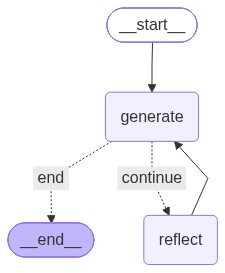

In [7]:
display(Image(reflection_graph.get_graph().draw_mermaid_png()))

In [8]:
task = "배송이 2주 지연된 고객에게 사과 이메일을 작성해줘. 고객명: 김민수, 주문번호: ORD-2024-1234"

result = reflection_graph.invoke(
    {"messages": [HumanMessage(content=task)], "iteration": 0}
)

print(f"총 반복 횟수: {result['iteration']}")
print(f"총 메시지 수: {len(result['messages'])}")
print("\n" + "=" * 60)

for msg in result["messages"]:
    print(f"\n[{msg.type}]")
    print(msg.text[:500])
    print("-" * 40)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


총 반복 횟수: 3
총 메시지 수: 6


[human]
배송이 2주 지연된 고객에게 사과 이메일을 작성해줘. 고객명: 김민수, 주문번호: ORD-2024-1234
----------------------------------------

[ai]
제목: [안내] 주문하신 상품(ORD-2024-1234)의 배송 지연에 대해 깊이 사과드립니다.

김민수 고객님, 안녕하십니까.

먼저 저희 제품을 믿고 구매해 주신 고객님께 심려를 끼쳐드려 진심으로 사과드립니다.

고객님께서 주문하신 상품(주문번호: ORD-2024-1234)이 예상치 못한 물류량 급증 및 입고 검수 과정의 차질로 인해 안내해 드린 일정보다 약 2주간 배송이 지연되었습니다. 상품을 설레는 마음으로 기다리셨을 고객님께 불편을 드린 점, 당사의 불찰이며 책임이 큼을 인지하고 있습니다.

현재 지연되었던 물량의 검수 및 포장 작업이 완료되어, 고객님의 상품을 최우선 출고 대상으로 지정하였습니다. 해당 상품은 금일 즉시 출고될 예정이며, 배송이 시작되는 대로 운송장 번호를 문자 메시지와 이메일로 다시 안내해 드리겠습니다.

오래 기다려주신 고객님께 감사와 죄송한 마음을 담아, 다음 구매 시 사용하실 수 있는 10% 할인 쿠폰을 고객님의 계정으로 발급해 드렸습니다. 

혹시
----------------------------------------

[human]
- **예상 수령 일자 미기재**
  - 문제점: 금일 출고 예정이라는 내용은 있으나, 2주간 배송을 기다린 고객 입장에서 실제로 상품을 언제 받을 수 있는지에 대한 예상 수령 시점이 명시되어 있지 않습니다.
  - 수정 방향: '금일 즉시 출고' 안내와 함께 택배사 사정을 고려한 대략적인 예상 수령 일자(예: 출고 후 영업일 기준 1~2일 내 수령 예정)를 명시하여 불확실성을 줄여주세요.

- **보상 쿠폰 상세 안내 부족**
  - 문제점: 지연 보상으로 제공되는 10% 할인 쿠폰의 유효기간이나 사용 조건이 기술되어 있지 않아 고객의 추가 문의가

In [9]:

for msg in result["messages"]:
    print(f"\n[{msg.type}]")
    print(msg.text)
    print("-" * 40)


[human]
배송이 2주 지연된 고객에게 사과 이메일을 작성해줘. 고객명: 김민수, 주문번호: ORD-2024-1234
----------------------------------------

[ai]
제목: [안내] 주문하신 상품(ORD-2024-1234)의 배송 지연에 대해 깊이 사과드립니다.

김민수 고객님, 안녕하십니까.

먼저 저희 제품을 믿고 구매해 주신 고객님께 심려를 끼쳐드려 진심으로 사과드립니다.

고객님께서 주문하신 상품(주문번호: ORD-2024-1234)이 예상치 못한 물류량 급증 및 입고 검수 과정의 차질로 인해 안내해 드린 일정보다 약 2주간 배송이 지연되었습니다. 상품을 설레는 마음으로 기다리셨을 고객님께 불편을 드린 점, 당사의 불찰이며 책임이 큼을 인지하고 있습니다.

현재 지연되었던 물량의 검수 및 포장 작업이 완료되어, 고객님의 상품을 최우선 출고 대상으로 지정하였습니다. 해당 상품은 금일 즉시 출고될 예정이며, 배송이 시작되는 대로 운송장 번호를 문자 메시지와 이메일로 다시 안내해 드리겠습니다.

오래 기다려주신 고객님께 감사와 죄송한 마음을 담아, 다음 구매 시 사용하실 수 있는 10% 할인 쿠폰을 고객님의 계정으로 발급해 드렸습니다. 

혹시 배송 지연으로 인해 주문 취소를 원하시거나 추가 문의 사항이 있으시다면, 언제든지 본 이메일의 답장 또는 고객센터로 연락해 주시기 바랍니다. 확인하는 대로 신속하게 처리해 드리겠습니다.

다시는 이와 같은 배송 지연이 발생하지 않도록 물류 시스템 및 입고 관리를 강화하겠습니다. 고객님의 소중한 기다림에 부응하지 못한 점 다시 한번 고개 숙여 사과드립니다.

감사합니다.

고객지원팀 드림
----------------------------------------

[human]
- **예상 수령 일자 미기재**
  - 문제점: 금일 출고 예정이라는 내용은 있으나, 2주간 배송을 기다린 고객 입장에서 실제로 상품을 언제 받을 수 있는지에 대한 예상 수령 시점이 명시되어 있지 않습니다

반복할수록 피드백이 반영되어 품질이 올라가는 것을 확인할 수 있다. 하지만 Reflection에는 한계가 있다.

- 피드백이 **자연어**라서 "얼마나 좋아졌는지" 정량화할 수 없다
- "충분히 좋다"의 기준이 없으므로 항상 `max_iterations`까지 반복한다
- 반복할수록 피드백이 점점 미세해져 표현 수준의 차이만 지적할 수 있다. 이것이 실질적 개선인지는 별도로 판단해야 한다
- 반복이 많아지면 원래 의도에서 벗어나거나 과하게 수정되는 경우도 있다 (항상 품질이 올라가는 것은 아니다)

Evaluator-Optimizer 패턴은 루브릭과 합격 기준을 명시해 종료 시점과 개선 대상을 더 분명하게 만든다. 다만 평가자가 LLM이라면 점수의 주관성과 실행별 변동성은 여전히 남는다.

### Evaluator-Optimizer 패턴

Reflection과 구조는 비슷하지만 핵심 차이가 있다.

| | Reflection | Evaluator-Optimizer |
|---|---|---|
| 평가 결과 | 자유 형식의 자연어 피드백 | 항목별 점수와 근거를 구조화해 반환 |
| 종료 조건 | 주로 고정 횟수 | 합격 기준 달성 또는 최대 횟수 도달 |
| 개선 범위 | 전체적인 피드백 | 기준에 미달한 항목을 우선 개선 |
| 판정 특성 | 종료 판단이 명시적이지 않음 | 기준은 명시적이지만 LLM 점수는 달라질 수 있음 |

```
START → generate → evaluate → pass → END
          ↑            │ fail
          └── optimize ←┘
```

시나리오: 마케팅 카피 생성. 루브릭으로 평가하고, 미달 항목에 대한 수정 지시를 만든 뒤 다시 생성한다. 점수는 품질을 객관적으로 보장하는 값이 아니라 흐름을 제어하기 위한 구조화된 판단으로 사용한다.

### 루브릭 설계

루브릭(Rubric)은 **평가 항목과 점수 기준을 정리한 채점표**다. 좋은 루브릭은 구체적이고 측정 가능하다.

| 나쁜 루브릭 | 좋은 루브릭 |
|------------|------------|
| "매력적인가?" | "감정을 자극하는 단어가 1개 이상 포함되어 있는가?" |
| "적절한 길이인가?" | "50자 이상 150자 이하인가?" |
| "좋은 카피인가?" | "행동 유도(CTA)가 포함되어 있는가?" |

Pydantic 모델로 평가 결과를 구조화한다.

In [15]:
class CriterionResult(BaseModel):
    score: int = Field(description="1~10 점수", ge=1, le=10)
    reason: str = Field(description="점수 근거 (1문장)")


class EvaluationResult(BaseModel):
    clarity: CriterionResult = Field(description="핵심 가치 전달 평가")
    emotion: CriterionResult = Field(description="타겟 공감과 변화 표현 평가")
    cta: CriterionResult = Field(description="행동 유도 평가")
    conciseness: CriterionResult = Field(description="길이와 중복 표현 평가")
    summary: str = Field(description="전체 평가 요약 (1~2문장)")

루브릭은 도메인마다 완전히 달라진다. 마케팅 카피라면 "감정 자극, CTA 포함, 글자 수", 기술 문서라면 "정확성, 재현 가능성, 코드 포함" 등이 핵심 기준이 된다. 설계할 때는 해당 도메인의 핵심 품질 기준을 먼저 정의하고, 각 기준을 측정 가능한 형태로 변환한 뒤, 점수 척도와 합격 기준을 설정한다.

In [16]:
class EvalOptState(TypedDict):
    task: str
    copy: str
    evaluation: dict  # EvaluationResult를 dict로 저장
    iteration: int
    history: Annotated[list, add]  # 이전 카피, 평가 결과, 개선 지시 누적


MAX_ITERATIONS = 4
PASS_THRESHOLD = 8
EVALUATION_CRITERIA = ("clarity", "emotion", "cta", "conciseness")
evaluator_llm = ChatGoogleGenerativeAI(model=MODEL_NAME)
evaluator = evaluator_llm.with_structured_output(EvaluationResult)

In [ ]:
def generate_copy(state: EvalOptState):
    """마케팅 카피를 생성한다. 이전 평가가 있으면 optimize 노드의 지시를 참고한다."""
    task = state["task"]
    history = state.get("history", [])

    if history:
        last = history[-1]
        prompt = (
            f"작업: {task}\n\n"
            f"이전 카피:\n{last['copy']}\n\n"
            f"개선 지시:\n{last['improvement']}\n\n"
            "위 지시를 반영해서 카피를 다시 작성해. 카피만 출력해."
        )
    else:
        prompt = f"다음 마케팅 카피를 작성해. 카피만 출력해.\n\n작업: {task}"

    response = generator_llm.invoke(prompt)
    return {"copy": response.text}


def evaluate_copy(state: EvalOptState):
    """루브릭에 따라 카피를 채점한다. Structured Output 사용."""
    copy = state["copy"]
    system = SystemMessage(content="""
너는 마케팅 카피 평가자다. 각 항목을 1~10점으로 평가하고 근거를 한 문장으로 작성하라.

평가 기준:
- clarity: 출퇴근 10분과 영어 실력 향상을 모두 명확히 전달하면 8점 이상
- emotion: 타겟이 공감할 문제나 기대할 변화를 구체적으로 표현하면 8점 이상
- cta: 독자가 즉시 실행할 수 있는 직접적인 행동 유도가 있으면 8점 이상
- conciseness: 공백 포함 50~150자이고 중복 표현이 없으면 8점 이상

기준을 충족하지 못한 항목에는 7점 이하를 부여하라.
""")
    result = evaluator.invoke([
        system,
        HumanMessage(content=f"<copy>\n{copy}\n</copy>"),
    ])

    evaluation = result.model_dump()
    evaluation["overall_pass"] = all(
        evaluation[name]["score"] >= PASS_THRESHOLD
        for name in EVALUATION_CRITERIA
    )

    return {
        "evaluation": evaluation,
        "iteration": state.get("iteration", 0) + 1,
    }


def optimize_copy(state: EvalOptState):
    """미달 항목의 평가 근거를 바탕으로 다음 생성에 사용할 수정 지시를 만든다."""
    evaluation = state["evaluation"]
    failed = [
        (name, evaluation[name])
        for name in EVALUATION_CRITERIA
        if evaluation[name]["score"] < PASS_THRESHOLD
    ]
    failed_items = [
        f"- {name} ({criterion['score']}점): {criterion['reason']}"
        for name, criterion in failed
    ]

    response = generator_llm.invoke(
        """너는 마케팅 카피 개선 편집자다. 평가 기준에 미달한 항목만 분석해
다음 생성 단계가 바로 적용할 수 있는 구체적인 수정 지시를 작성하라.
카피를 직접 다시 쓰지 말고, 유지할 내용과 바꿀 내용을 명확히 구분하라.
평가에 없는 새로운 제품 정보는 추가하지 마라.

<task>
""" + state["task"] + """
</task>

<current_copy>
""" + state["copy"] + """
</current_copy>

<failed_criteria>
""" + "\n".join(failed_items) + """
</failed_criteria>"""
    )

    return {
        "history": [{
            "copy": state["copy"],
            "evaluation": evaluation,
            "improvement": response.text,
        }],
    }


def should_continue_eval(state: EvalOptState):
    if state["evaluation"]["overall_pass"]:
        return "end"
    if state["iteration"] >= MAX_ITERATIONS:
        return "end"  # 상한 도달 시에도 종료
    return "fail"

In [13]:
builder = StateGraph(EvalOptState)

builder.add_node("generate", generate_copy)
builder.add_node("evaluate", evaluate_copy)
builder.add_node("optimize", optimize_copy)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")
builder.add_conditional_edges(
    "evaluate",
    should_continue_eval,
    {"end": END, "fail": "optimize"},
)
builder.add_edge("optimize", "generate")

eval_opt_graph = builder.compile()

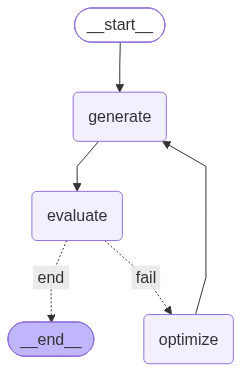

In [14]:
display(Image(eval_opt_graph.get_graph().draw_mermaid_png()))

In [17]:
task = "AI 기반 영어 학습 앱 'SmartLingo' 출시 광고 카피. 타겟: 20~30대 직장인. 핵심 가치: 출퇴근 10분으로 영어 실력 향상."

for event in eval_opt_graph.stream({"task": task, "iteration": 0, "history": []}):
    node_name = list(event.keys())[0]
    state_update = event[node_name]

    if node_name == "generate":
        print(f"\n{'=' * 60}")
        print(f"[generate] 카피 생성")
        print(state_update["copy"])

    elif node_name == "evaluate":
        iteration = state_update["iteration"]
        evaluation = state_update["evaluation"]
        status = "PASS ✓" if evaluation["overall_pass"] else "FAIL ✗"
        print(f"\n[evaluate] 반복 {iteration} — {status}")
        for name in EVALUATION_CRITERIA:
            criterion = evaluation[name]
            mark = "PASS" if criterion["score"] >= PASS_THRESHOLD else "FAIL"
            print(f"  {name}: {criterion['score']}/10 ({mark}) - {criterion['reason']}")

    elif node_name == "optimize":
        h = state_update["history"][0]
        print(f"\n[optimize] 개선 지시")
        print(h["improvement"])


[generate] 카피 생성
[메인 헤드라인]
오늘도 출퇴근길에 멍하니 폰만 보셨나요?
하루 10분, 지하철이 당신의 영어 학원이 됩니다.

[서브 헤드라인]
바쁜 2030 직장인을 위한 AI 맞춤 영어 솔루션, SmartLingo

[바디 카피]
야근에 치이고, 피곤에 지친 일상 속
영어 공부, 아직도 거창하게 시작하시나요?

SmartLingo는 당신의 정체된 출퇴근 10분을 
가장 스마트한 영어 스펙업 시간으로 바꿔드립니다.

• AI의 1:1 초개인화 맞춤 레벨 케어
• 지하철, 버스에서 부담 없이 끝내는 10분 숏폼 학습
• 실무와 일상에서 바로 쓰는 진짜 실전 표현

[CTA]
오늘 퇴근길부터 시작하세요.
[SmartLingo 지금 무료로 체험하기]

[evaluate] 반복 1 — FAIL ✗
  clarity: 9/10 (PASS) - 출퇴근길 10분 활용과 영어 실력 향상이라는 핵심 가치를 매우 명확하게 전달하고 있습니다.
  emotion: 9/10 (PASS) - 피곤한 직장인의 일상에 공감하면서 출퇴근 시간을 활용한 변화를 구체적으로 제시하고 있습니다.
  cta: 9/10 (PASS) - 오늘 퇴근길부터 시작하라는 메시지와 함께 무료 체험 버튼으로 즉각적인 행동을 유도합니다.
  conciseness: 6/10 (FAIL) - 공백 포함 글자 수가 약 280자로 기준인 150자를 초과하여 개선이 필요합니다.

[optimize] 개선 지시
[미달 항목 분석 및 수정 지시]

**평가 미달 항목: conciseness (간결성)**
*   **분석:** 현재 원문은 공백 포함 약 280자로, 목표 기준인 150자를 약 130자 초과함. 서두의 감성적 질문과 서술형 문장이 분량을 늘리고 있어, 핵심 메시지 중심으로 대폭 압축이 필요함.

---

### 1. 유지할 내용 (Keep)
*   **핵심 타겟:** 2030 직장인
*   **핵심 가치/소구점:** 출퇴근 시간 10분 활용, AI 맞춤 학습, 실전 표현
*   **필수 요소:*

주의: 이 예제에서는 같은 LLM이 생성과 평가를 모두 수행한다. 합격 규칙을 코드로 고정해도 LLM이 매기는 점수는 실행마다 달라질 수 있다. 실무에서는 평가에 더 강한 모델을 쓰거나, 생성 모델과 별도의 모델을 사용해서 자기 평가 편향(self-evaluation bias)을 줄이기도 한다.

### 실습: 제품 리뷰 요약

아래 제품 리뷰를 한 문단(3~5문장)으로 요약하는 과제를 두 가지 패턴으로 구현한다.

- **Reflection**: generate → should_continue → reflect 루프
- **Evaluator-Optimizer**: generate → evaluate → optimize 루프

실무에서 Evaluator-Optimizer를 쓸 때 **루브릭 설계가 가장 중요한 단계**다. 루브릭이 모호하면 점수가 들쭉날쭉해서 Reflection과 다를 바 없고, 루브릭이 구체적이면 개선 방향이 명확해진다.

### 샘플 리뷰 데이터

In [ ]:
REVIEW = """\
[무선 블루투스 이어폰 - StarBuds Pro 리뷰]

저는 이 이어폰을 출퇴근용으로 3개월째 사용하고 있습니다. 먼저 음질은 가격대비 정말 \
훌륭합니다. 저음이 풍부하고 고음도 깨끗하게 들립니다. 특히 팟캐스트를 들을 때 목소리가 \
또렷하게 들려서 좋습니다.

노이즈 캔슬링은 지하철에서 테스트해봤는데, 완전 차단까지는 아니지만 주변 소음을 \
70~80% 정도 줄여줍니다. 출퇴근 시 음악 감상에는 충분합니다. 다만 바람이 부는 야외에서는 \
노캔 성능이 많이 떨어집니다.

배터리는 공식 스펙이 7시간인데 실사용 5시간 반 정도 갑니다. 노캔 켜면 4시간 정도로 \
줄어듭니다. 케이스 충전 포함하면 총 20시간 정도 사용 가능합니다.

착용감은 제 귀에는 잘 맞는데, 귀가 작은 아내는 30분만 끼면 아프다고 합니다. 이어팁이 \
3종류 들어있긴 한데 가장 작은 것도 좀 큰 편입니다.

통화 품질은 솔직히 별로입니다. 상대방이 제 목소리가 멀리서 들린다고 합니다. \
조용한 실내에서는 괜찮은데 밖에서는 통화하기 어렵습니다.

앱 연동은 EQ 조절이 가능하고 노캔 강도도 조절할 수 있어서 편리합니다. \
다만 앱이 가끔 블루투스 연결이 끊기는 버그가 있습니다.

총평: 7만원대에 이 정도면 가성비 좋습니다. 통화보다 음악 감상 위주로 쓸 분께 추천합니다. \
통화를 많이 하시는 분은 다른 제품을 알아보시는 게 좋을 것 같습니다.
"""

print(REVIEW)

### Reflection으로 리뷰 요약

위에서 배운 Reflection 패턴을 사용해서 리뷰를 한 문단(3~5문장)으로 요약하는 그래프를 구현하라. 장점, 단점, 추천 대상을 균형 있게 포함하고, 반복적인 검토를 통해 요약을 개선한다.

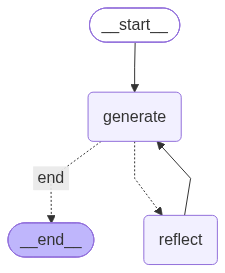

In [5]:
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

# 완성한 그래프를 review_reflection_graph에 저장하세요.

class State(TypedDict):
    # request: str
    # result : str
    # review : str
    # messages로 합쳐질 수 있더라.
    messages: Annotated[list, add_messages]
    iteration: int

# from langgraph.graph import MessagesState
# class State(MessagesState):
#     iteration: int

# 를 활용해도 좋습니다.

def generate(state: State):
    iteration = state.get('iteration', 0)
    # 1. 시스템 프롬프트 마련해서
    # 2. 입력받은 요청으로 작성을 하고
    # 3. state를 업데이트한다.

    # 시스템 프롬프트에 자세한 지시사항이 들어가야 합니다.
    system_prompt = SystemMessage(content="""
입력받은 리뷰를 요약해줘.
요약한 결과만 응답해줘.
""")
    response = llm.invoke([system_prompt, *state['messages']])

    return {
        'messages' : [response],
        'iteration' : iteration + 1
        }

def reflect(state: State):
    request = state['messages'][0]
    result = state['messages'][-1]
    system_prompt = SystemMessage(content="""
<result>는 <request>에 대한 요약문이야.
다음 기준으로 리뷰해줘
- request를 요약하는 과정에서 편향되지 않은지 판단해줘.
- request에 요약하는 과정에서 정보가 누락되지 않은지 판단해줘.

- review 결과만 응답해.
""")
    human_prompt = HumanMessage(content=f"""
<request>{request}</request>
<result>{result}</result>
""")
    # 지금은 ai message 상태.
    response = llm.invoke([system_prompt, human_prompt])

    # 마치 사용자가 review한것처럼 꾸미기 위해서 human message로 바꾼다.
    response = HumanMessage(content=response.text)

    return {
        'messages' : [response],
        }

def should_continue(state: State):
    iteration = state['iteration']

    if iteration >= 2:
        return 'end'
    return 'reflect'


builder = StateGraph(State)

builder.add_node('generate', generate)
builder.add_node('reflect', reflect)

builder.add_edge(START, 'generate')
builder.add_edge('reflect', 'generate')

builder.add_conditional_edges(
    'generate',
    should_continue,
    {
        'reflect': 'reflect',
        'end': END
    }
)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
graph.invoke({'message': f"<review>{REVIEW}<review>"})

### Evaluator-Optimizer로 리뷰 요약

같은 리뷰를 Evaluator-Optimizer 패턴으로 요약한다. 아래 루브릭은 구현을 돕기 위한 참고 예시이며, 그대로 사용할 필요는 없다. 필요에 따라 평가 항목과 기준을 수정하거나 추가한다. 모든 항목이 8점 이상이면 통과한다.

루브릭 (각 1~10점):
- completeness: 원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었는가?
- accuracy: 가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하며, 원문에 없는 정보를 추가하지 않았는가?
- conciseness: 핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었는가?
- recommendation: 적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했는가?

In [ ]:
# 완성한 그래프를 review_eval_opt_graph에 저장하세요.
# 최종 요약은 summary, 평가 결과는 evaluation에 저장하세요.

# Rublic
class EvalutionResultItem(BaseModel):
    score: int = Field(description="1 ~ 10 사이의 정수 점수")
    reason: str = Field(description="score를 매긴 이유")

class EvalutionResult(BaseModel):
    completeness: EvalutionResultItem = Field(description="원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었는가?")
    accuracy: EvalutionResultItem = Field(description="가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하며, 원문에 없는 정보를 추가하지 않았는가?")
    conciseness: EvalutionResultItem = Field(description="핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었는가?")
    recommendation: EvalutionResultItem = Field(description="적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했는가?")

llm_with_rubric = llm.with_structured_output(EvalutionResult)

# State
class State(TypedDict):
    request: str
    result: str
    evalution: dict

    # 
    history: list

def generate(state: State):
    request = state['request']
    system_prompt = """
입력받은 리뷰를 요약해줘.
다음 기준에 부합하도록 요약해줘.
평가 결과가 있다면 그것을 반영해줘. 

- 원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었는가?
- 가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하며, 원문에 없는 정보를 추가하지 않았는가?
- 핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었는가?
- 적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했는가?
"""
    evalution = state.get('evalution', None)

    if evalution:
        additional_prompt = "평가 결과 : "
        # 원래 evalution은
        # {기준 : {score : , reason : }}
        # 의 형태라 조금 더 복잡한 형태로 prompt에 넣어줘야 합니다.
        for key, value in evalution.items():
            additional_prompt += f"{key} {value}"

        system_prompt += additional_prompt

    system_prompt = SystemMessage(content=system_prompt)
    human_message = HumanMessage(content=request)
    result = llm.invoke([system_prompt, human_message])

    return { 'result' : result.text }

def evalutaion(state: State):
    # request, result 를 바탕으로 evalute할겁니다.
    # 근데 루브릭이 존재합니다.
    request = state['request']
    result = state['result']
    system_prompt = SystemMessage(content="""
<result>는 <request>에 대한 요약문이야.

다음 기준에 부합하도록 리뷰해줘.

- 원문의 핵심 장점과 단점이 각각 1개 이상 포함되고, 가격 정보가 반영되었는가?
- 가격, 사용 시간, 성능 등 제품 정보가 원문과 일치하며, 원문에 없는 정보를 추가하지 않았는가?
- 핵심 정보의 불필요한 반복 없이 3~5문장으로 작성되었는가?
- 적합한 사용자와 부적합한 사용자를 원문의 근거에 따라 모두 언급했는가?
""")
    human_prompt = HumanMessage(content=f"""
<request>{request}</request>
<result>{result}</result>
""")
    result = llm_with_rubric.invoke([system_prompt, human_prompt])

    # history를 담아서, 마지막 result / evalution 뿐만 아니라
    # 전체적인 과정을 디버깅하듯이 볼 수 있다.
    return {'evalution' : result.model_dump() }

def should_continue(state: State):
    # 점수를 확인해서
    evalution = state['evalution']
    score를 확인하고 ~

    if 충분하면 :
        return 'end'

    return 'generate'


builder = StateGraph(State)

builder.add_node('generate', generate)
builder.add_node('evalutaion', evalutaion)

builder.add_edge(START, 'generate')
builder.add_edge('generate', 'evalutaion')

builder.add_conditional_edges(
    'evalutaion',
    should_continue,
    {
        'generate': 'generate',
        'end': END
    }
)
